In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy
!pip install optuna

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.7 MB/s eta 0:00:00
⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
!pip install -U transformers pysentimiento emoji umap-learn -q
import os
import string
import warnings
import torch
import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import umap

from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pysentimiento import create_analyzer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.7 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# CELL 1: RAW OCR EXTRACTION & STRATEGIC GROUPING (JOIN BY NUMERIC SUFFIX)
# ==============================================================================

print("⏳ Forging the Golden Link between OCR and Silver via Substring Join...")

# JOIN inteligente: ignoramos "OCR" (3 chars) y "OF" (2 chars) para unir por el número
query = """
SELECT
    r.ocr_id,
    s.offer_id,
    r.dropoff_address as raw_address,
    s.dropoff_polygon_id,
    s.dropoff_hdbscan_id,
    s.dropoff_polygon_name,
    s.dropoff_hdbscan_name
FROM raw_offers_ocr r
JOIN silver_palette s ON SUBSTR(r.ocr_id, 4) = SUBSTR(s.offer_id, 3)
WHERE r.dropoff_address IS NOT NULL
"""
df_input = pd.read_sql(query, db_engine)

if len(df_input) > 0:
    print(f"✅ Success! Joined {len(df_input)} raw records.")
else:
    print("❌ Critical: Join still returned 0 rows. Please verify if suffixes align (e.g., OCR00001 vs OF00001).")

# --- STRATEGIC GROUPING (Salchichota Logic - Identical as requested) ---
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(
    lambda x: "__".join(sorted([str(i) for i in x if pd.notna(i) and i != 'unassigned']))
).to_dict()
name_foundry[-1] = "unassigned"

df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)
print("✅ Naming Forge Complete.")

⏳ Forging the Golden Link between OCR and Silver via Substring Join...
✅ Success! Joined 4752 raw records.
✅ Naming Forge Complete.


In [ ]:
# ==============================================================================
# CELL 1.3 + 2: MASTER COALESCE & URBAN STANDARDIZER
# ==============================================================================
# Mission: 1. Finalize the target zone labels with Airport Fusion.
#          2. THEN apply the definitive standardization function.
# ==============================================================================
import regex as re

# --- Definimos la Función ANTES de usarla ---
def standardize_mexico_city_address(text):
    if not isinstance(text, str) or text.lower() in ['null', 'n/a']:
        return "unknown_address"
    t = text.lower()
    t = t.replace('sante fe', 'santa fe').replace('sta fe', 'santa fe').replace('sta fé', 'santa fe').replace('aicm', 'aeropuerto')
    t = re.sub(r'\b(av|ave|avenida|av\.|av_)\b', 'av', t)
    t = re.sub(r'\b(cll|calle|cll\.|cl\.)\b', 'calle', t)
    t = re.sub(r'\b(pº|p de|paseo de|pso|p\.º)\b', 'paseo', t)
    t = re.sub(r'\b(\d{5})\b', r'cp\1', t)
    for _ in range(3):
        t = re.sub(r'(\b\p{L}+(?:_\p{L}+|_\d+)*)\s+(\d{1,4}|norte|sur|este|oeste|poniente|oriente)\b', r'\1_\2', t)
    t = re.sub(r'\b(mexico|méxico|cdmx|ciudad de mexico|df|d\.f\.)\b', '', t)
    t = re.sub(r'[^a-z0-9áéíóúüñ_\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t


# --- Ahora ejecutamos el Coalesce ---
print("⏳ Executing Master Coalesce with Airport Fusion...")

# A. Logic for final_zone_id
conditions_id = [(df_input['id_agrupado'] >= 0), (df_input['dropoff_hdbscan_id'] > -1)]
choices_id = ["P_" + df_input['id_agrupado'].astype(int).astype(str),
              "C_" + df_input['dropoff_hdbscan_id'].fillna(-1).astype(int).astype(str)]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name
conditions_name = [(df_input['id_agrupado'] >= 0), (df_input['dropoff_hdbscan_id'] > -1)]
choices_name = [df_input['grouped_polyname'], df_input['dropoff_hdbscan_name']]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# C. LA FUSIÓN ESTRATÉGICA (AEROPUERTO)
df_input['final_zone_name'] = df_input['final_zone_name'].replace({
    'terminal_1_aicm': 'aicm_aeropuerto',
    'terminal_2_aicm': 'aicm_aeropuerto'
})

# Asumimos que los IDs de HDBSCAN para T1 y T2 son 4 y 5
# (Puedes verificar esto en tu auditoría si falla)
df_input['final_zone_id'] = df_input['final_zone_id'].replace({'C_5': 'C_4'})


# --- Aislamiento del Set de Entrenamiento y Estandarización Final ---
df_nav = df_input[df_input['final_zone_name'] != "Unassigned Area"].copy()
df_nav = df_nav.rename(columns={'raw_address': 'dropoff_address'})

print("⏳ Forging FINAL Standardized Addresses...")
df_nav['clean_address'] = df_nav['dropoff_address'].apply(standardize_mexico_city_address)


print(f"\n✅ Training Set Ready: {len(df_nav)} observations.")
print(f"✅ Airport Fusion: {len(df_nav[df_nav['final_zone_name'] == 'aicm_aeropuerto_total'])} samples for AICM.")
print(f"✅ Final Target Complexity: {df_nav['final_zone_id'].nunique()} unique zones.")

⏳ Executing Master Coalesce with Airport Fusion...
⏳ Forging FINAL Standardized Addresses...

✅ Training Set Ready: 3389 observations.
✅ Airport Fusion: 0 samples for AICM.
✅ Final Target Complexity: 65 unique zones.


In [ ]:
# ==============================================================================
# NLP CONTEXT RESTORATION
# ==============================================================================
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Asegurar descarga de recursos
try:
    nltk.download('stopwords', quiet=True)
    # Crear la lista bilingüe que el sistema perdió al reiniciar
    stop_words_bilingual = list(set(stopwords.words('spanish') + stopwords.words('english')))
    print(f"✅ Stopwords Bilingües restauradas: {len(stop_words_bilingual)} tokens.")
except Exception as e:
    print(f"❌ Error al restaurar stopwords: {e}")

# 2. Definir target_zones (necesario para los loops de análisis posteriores)
if 'df_nav' in locals():
    target_zones = df_nav['final_zone_name'].unique()
    print(f"✅ Target Zones re-indexadas: {len(target_zones)}")
else:
    print("⚠️ Advertencia: df_nav no detectado. Asegúrate de haber corrido la extracción de datos.")

✅ Stopwords Bilingües restauradas: 504 tokens.
✅ Target Zones re-indexadas: 64


In [ ]:
# ==============================================================================
# CELL 2: THE URBAN STANDARDIZER (Nivel 0) - HARD-CUT EDITION
# ==============================================================================
import regex as re
import unicodedata

def standardize_mexico_city_address(text):
    if not isinstance(text, str) or text.lower() in ['null', 'n/a']:
        return "unknown_address"

    t = text.lower()
    t = "".join(c for c in unicodedata.normalize('NFKD', t) if not unicodedata.combining(c))
    # --- 1. OPERATION: HARD-CUT (THE GUILLOTINE) ---
    # Buscamos el primer slash.
    # Eliminamos el slash, todo lo que viene después, Y la palabra que está justo antes.
    # Regex: (\s+\S+)?\s*/.*$  -> Busca (opcionalmente un espacio y una palabra)
    # seguido de (espacio y slash) y (todo lo demás hasta el fin de la línea).
    t = re.sub(r'\s*\S+\s*/.*$', '', t)
    # -----------------------------------------------

    # 2. Correcciones Heurísticas
    t = t.replace('sante fe', 'santa fe').replace('sta fe', 'santa fe')
    t = t.replace('aicm', 'aeropuerto')

    # 3. Unificación de Prefijos (Gramática)
    t = re.sub(r'\b(av|ave|avenida|av\.|av_)\b', 'av', t)
    t = re.sub(r'\b(cll|calle|cll\.|cl\.)\b', 'calle', t)
    t = re.sub(r'\b(pº|p de|paseo de|pso|p\.º)\b', 'paseo', t)

    # 4. PROTECCIÓN DE CPs (5 dígitos)
    t = re.sub(r'\b(\d{5})\b', r'cp\1', t)

    # 5. FUSIÓN RECURSIVA (Street + Number/Cardinal)
    # Aquí es donde preservamos la señal de altura si sobrevivió al corte
    for _ in range(3):
        t = re.sub(r'(\b\p{L}+(?:_\p{L}+|_\d+)*)\s+(\d{1,4}|norte|sur|este|oeste|poniente|oriente)\b', r'\1_\2', t)

    # 6. Neutralización de Ruido Administrativo Restante
    # (Por si acaso algunas zonas no tenían slash pero están en nuestra lista negra)
    # Usamos la lista 'domain_noise' que ya identificamos en el nivel 1
    if 'domain_noise' in locals():
        for noise in domain_noise:
            t = re.sub(rf'\b{noise}\b', '', t)

    # 7. Purificación Unicode Final
    t = re.sub(r'[^a-z0-9áéíóúüñ_\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()

    return t

print("⏳ Executing 'Operation: Hard-Cut' on all addresses...")
df_nav['clean_address'] = df_nav['dropoff_address'].apply(standardize_mexico_city_address)

print("\n--- HARD-CUT CHECK (Testing your Edge Cases) ---")
samples = [
    "Hamburgo 263 / Juárez",               # Should output "hamburgo" or "hamburgo 263" depending on the cut
    "Polanco / Anzures",                   # Should output empty string (both are noise)
    "Satelite / Lomas Verdes",             # Should output empty string
    "Cuahtemoc / Juarez",                  # Should output empty string
    "Paseo de la Refórma 2600 / Lomas"     # Should output "paseo de la reforma" (preserving the main street)
]
for s in samples:
    print(f"IN:  {s}")
    print(f"OUT: {standardize_mexico_city_address(s)}")
    print("-" * 30)

⏳ Executing 'Operation: Hard-Cut' on all addresses...

--- HARD-CUT CHECK (Testing your Edge Cases) ---
IN:  Hamburgo 263 / Juárez
OUT: hamburgo
------------------------------
IN:  Polanco / Anzures
OUT: 
------------------------------
IN:  Satelite / Lomas Verdes
OUT: 
------------------------------
IN:  Cuahtemoc / Juarez
OUT: 
------------------------------
IN:  Paseo de la Refórma 2600 / Lomas
OUT: paseo la reforma
------------------------------


In [ ]:
# ==============================================================================
# CELL 3.1: GLOBAL NOISE FILTER (Restoration)
# ==============================================================================
print("⏳ Re-establishing global stopword barrier...")

# 1. Base Bilingual List
import nltk
from nltk.corpus import stopwords
try:
    nltk.download('stopwords', quiet=True)
    stop_words_bilingual = set(stopwords.words('spanish') + stopwords.words('english'))
except:
    stop_words_bilingual = set()

# 2. Add structural CDMX noise (Words that appear everywhere)
# These are words that survived the "Hard-Cut" but carry zero geographic signal.
structural_noise = {
    'mexico', 'cdmx', 'ciudad', 'méxico', 'mex', 'méx', 'df', 'd.f.'
}

final_stopwords_v2 = list(stop_words_bilingual.union(structural_noise))

print(f"✅ Stopword list restored: {len(final_stopwords_v2)} tokens.")

⏳ Re-establishing global stopword barrier...
✅ Stopword list restored: 512 tokens.


In [ ]:
# ==============================================================================
# CELL 3.2: TF-IDF - THE PURE STREET SIGNALS
# ==============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer

print("⏳ Extracting signals from Hard-Cut addresses...")

# We use ngram_range (1,2) to catch fused anchors like 'reforma_505'
tfidf_final = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2500,
    min_df=2,
    stop_words=final_stopwords_v2
)

X_tfidf_final = tfidf_final.fit_transform(df_nav['clean_address'])
features_final = tfidf_final.get_feature_names_out()

# Re-run the zone analysis to see the "Diamonds"
final_analysis = []
for zone in df_nav['final_zone_name'].unique():
    mask = (df_nav['final_zone_name'] == zone)
    zone_matrix = X_tfidf_final[mask.values]
    mean_weights = zone_matrix.mean(axis=0).A1
    top_indices = mean_weights.argsort()[-5:][::-1]
    top_tokens = [features_final[i] for i in top_indices]

    final_analysis.append({
        'Zone': zone,
        'Top_Signals': ", ".join(top_tokens)
    })

display(pd.DataFrame(final_analysis).head(15))

# Materialize the analysis into the missing DataFrame
df_lexicon = pd.DataFrame(final_analysis)

⏳ Extracting signals from Hard-Cut addresses...


,Zone,Top_Signals
0,lomas_fc_cuernavaca,"lomas chapultepec, chapultepec, lomas, cp11000..."
1,lomas_verdes,"naucalpan juarez, naucalpan, juarez, san, san ..."
2,fuentes_casino__sedena__tecamachalco,"lomas chapultepec, chapultepec, lomas, miguel,..."
3,plaza_satelite_mundo_e,"satelite, cp53100, cp53100 naucalpan, tlalnepa..."
4,polanco_parroquia,"polanco, miguel hidalgo, hidalgo, miguel, cp11550"
5,palmas_jp_morgan,"lomas chapultepec, chapultepec, lomas, hidalgo..."
6,santa_fe_ibero,"fe, santa, santa fe, alvaro obregon, obregon"
7,napoles_wtc,"napoles, benito juarez, benito, cp03810, juarez"
8,pedregal,"pedregal, tlalpan, jardines, jardines pedregal..."
9,de_las_fuentes__tecamachalco,"fuente, cp53950 naucalpan, cp53950, tecamachal..."


In [ ]:
# ==============================================================================
# CELL 4: PIENZA BABEL - WORD EMBEDDINGS (Nivel 2)
# ==============================================================================
# Mission: Train a Word2Vec model to discover the "Semantic Proximity"
#          of Mexico City's addresses.
# ==============================================================================

# --- 1. INSTALACIÓN (Si no está ya presente en el entorno) ---
print("Instalando librerías necesarias (gensim, scikit-learn)...")
!pip install -q gensim scikit-learn # Aseguramos gensim y sklearn
print("Librerías instaladas.")

# --- 2. IMPORTACIONES ---
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE # Para visualización alternativa (si la necesitas)
from gensim.models import Word2Vec # ¡Ahora sí!
from nltk.corpus import stopwords # Lo importamos por si acaso, aunque no se use aquí
from nltk.tokenize import word_tokenize
from nltk.util import ngrams # Para bigramas/trigramas si los necesitas
import regex as re
from collections import Counter
from google.colab import drive # Para Drive
import os # Para manejo de rutas
import multiprocessing

# --- 3. CONFIGURACIÓN ---
# Aseguramos que los recursos necesarios de NLTK estén descargados
try:
    stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords', quiet=True)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Montamos Drive si es necesario
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 4. PREPARACIÓN DE DATOS (CARGA Y LIMPIEZA) ---
if 'df_nav' not in locals():
    print("\n🔴 ERROR CRÍTICO: DataFrame 'df_nav' no encontrado. Por favor, ejecuta el Paso 1.3 primero.")
    raise SystemExit("Deteniendo ejecución. Necesitamos los datos limpios.")

# THE FIX: Split each string into a list of tokens
print("⏳ Tokenizing standardized addresses...")
sentences = [str(address).split() for address in df_nav['clean_address'].tolist()]

print(f"\n✅ Corpus ready! ({len(sentences)} documents tokenized).")
# Example check to ensure it worked: [['calle', 'reforma', '222'], ...]
print(f"Sample observation: {sentences[0][:5]}")


# --- 5. ENTRENAMIENTO DEL MODELO WORD2VEC ---
print("\n⏳ Training Pienza Babel's Semantic Engine (Word2Vec)...")

# Parámetros clave para Word2Vec
# - vector_size: La dimensionalidad de los embeddings (64).
# - window: El tamaño de la ventana de contexto (palabras que mira a la vez).
# - min_count: Ignora palabras que aparecen menos de X veces. Muy útil para el ruido.
# - sg=1: Skip-gram. Suele funcionar mejor con datasets pequeños/medianos.
# - workers: Usa todos los cores disponibles para acelerar.
# - seed: Para reproducibilidad.
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=64,         # Usamos 64 dimensiones, suficiente para capturar algo de semántica
    window=5,               # Ventana de contexto (palabras antes y después)
    min_count=5,            # Ignora palabras que aparecen menos de 5 veces
    sg=1,                   # Skip-gram model
    workers=multiprocessing.cpu_count(), # Usa todos los cores
    seed=42                 # Para reproducibilidad
)

print("✅ Word2Vec Training Complete.")

# --- 6. AUDITORÍA DE PROXIMIDAD SEMÁNTICA (EL PRUEBA DE FUEGO) ---
print("\n--- PIENZA BABEL: Semantic Proximity Audit ---")
test_tokens_semantico = ['santa', 'reforma', 'roma', 'interlomas', 'polanco', 'insurgentes']

for token in test_tokens_semantico:
    try:
        # Intentamos obtener la similaridad con las palabras más probables
        similares = w2v_model.wv.most_similar(token, topn=5)
        print(f"\n📍 Anchor Token: '{token}'")
    except KeyError:
        print(f"\n📍 Anchor Token: '{token}' (Not found in vocabulary, likely due to min_count or cleaning)")
        continue # Saltamos a la siguiente si no está en el vocabulario

    for t, sim in similares:
        print(f"   --> {t:<25} (Similarity: {sim:.3f})")

print("\n✅ Semantics Learned! Analyzing proximity patterns.")

Instalando librerías necesarias (gensim, scikit-learn)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.0 MB/s eta 0:00:00
Librerías instaladas.
⏳ Tokenizing standardized addresses...

✅ Corpus ready! (3389 documents tokenized).
Sample observation: ['calle', 'barrilaco', 'calle', 'sierra', 'mojada']

⏳ Training Pienza Babel's Semantic Engine (Word2Vec)...
✅ Word2Vec Training Complete.

--- PIENZA BABEL: Semantic Proximity Audit ---

📍 Anchor Token: 'santa'
   --> fe                        (Similarity: 0.977)
   --> zedec                     (Similarity: 0.971)
   --> cp05300                   (Similarity: 0.967)
   --> cp01330                   (Similarity: 0.954)
   --> cp01376                   (Similarity: 0.953)

📍 Anchor Token: 'reforma'
   --> paseo                     (Similarity: 0.932)
   --> o                         (Similarity: 0.890)
   --> p                         (Similarity: 0.884)
   --> prol                      (Similarity: 0.866)
   --> reforma_115   

In [ ]:
# ==============================================================================
# CELL 5: NEURAL PREPROCESSING & DATALOADERS
# ==============================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

print("⏳ Preparing Data for the Neural Engine...")

# 1. SAFETY PURGE (Stratified Split requires >= 2 samples per class)
MIN_SAMPLES = 2
zone_counts = df_nav['final_zone_id'].value_counts()
valid_zones = zone_counts[zone_counts >= MIN_SAMPLES].index
df_model = df_nav[df_nav['final_zone_id'].isin(valid_zones)].copy()
print(f"✅ Purged {len(df_nav) - len(df_model)} records belonging to ultra-rare zones.")

# 2. CONFIGURATION
MAX_LEN = 30  # Reduced slightly since clean_address is more compact
BATCH_SIZE = 32
VOCAB_SIZE = 2500

# 3. BUILD VOCABULARIES
# Using simple .split() because Level 0 already cleaned the text
all_tokens = [token for addr in df_model['clean_address'] for token in str(addr).split()]
token_counts = Counter(all_tokens)

vocab_tokens = ['<pad>', '<unk>'] + [token for token, count in token_counts.most_common(VOCAB_SIZE)]
token_to_idx = {token: i for i, token in enumerate(vocab_tokens)}

unique_zones = sorted(df_model['final_zone_id'].unique())
zone_to_idx = {zone: i for i, zone in enumerate(unique_zones)}
idx_to_zone = {i: zone for i, zone in enumerate(unique_zones)}

print(f"✅ Neural Vocab Size: {len(token_to_idx)} | Unique Target Zones: {len(unique_zones)}")

# 4. DATASET CLASS
class AddressDataset(Dataset):
    def __init__(self, addresses, labels, token_to_idx, zone_to_idx, max_len):
        self.addresses = addresses
        self.labels = labels
        self.token_to_idx = token_to_idx
        self.zone_to_idx = zone_to_idx
        self.max_len = max_len

    def __len__(self):
        return len(self.addresses)

    def __getitem__(self, idx):
        tokens = str(self.addresses[idx]).split()
        indices = [self.token_to_idx.get(t, self.token_to_idx['<unk>']) for t in tokens]

        if len(indices) < self.max_len:
            indices += [self.token_to_idx['<pad>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        label = self.zone_to_idx[self.labels[idx]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# 5. SPLIT & LOADERS
X = df_model['clean_address'].values
y = df_model['final_zone_id'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_loader = DataLoader(AddressDataset(X_train, y_train, token_to_idx, zone_to_idx, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AddressDataset(X_val, y_val, token_to_idx, zone_to_idx, MAX_LEN), batch_size=BATCH_SIZE)

print(f"✅ DataLoaders Ready. Train Size: {len(X_train)}, Val Size: {len(X_val)}")

⏳ Preparing Data for the Neural Engine...
✅ Purged 2 records belonging to ultra-rare zones.
✅ Neural Vocab Size: 2502 | Unique Target Zones: 63
✅ DataLoaders Ready. Train Size: 2709, Val Size: 678


In [ ]:
# ==============================================================================
# CELL 6: THE TRANSFORMER ARCHITECTURE
# ==============================================================================
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ZoneClassifierTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=128, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=256, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)
        self.d_model = d_model

    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1) # Global Average Pooling
        logits = self.classifier(x)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Architecture Deployed. Using Device: {device}")

🚀 Architecture Deployed. Using Device: cuda


In [ ]:
# ==============================================================================
# CELL 7: CHAMPION TRAINING (HIGH-PERFORMANCE DEFAULTS)
# ==============================================================================
# Note: Bypassing Optuna for immediate training. Using your established best parameters.
from sklearn.metrics import accuracy_score
import copy

print("⏳ Initializing Champion Training Phase...")

best_params = {'d_model': 256, 'nhead': 8, 'num_layers': 3, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 1e-4}

model = ZoneClassifierTransformer(
    vocab_size=len(token_to_idx),
    num_classes=len(unique_zones),
    d_model=best_params['d_model'],
    nhead=best_params['nhead'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
patience = 5
best_val_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())
no_improve_epochs = 0

print("-" * 60)
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    current_val_acc = accuracy_score(all_labels, all_preds)
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {current_val_acc:.4%}")

    if current_val_acc > best_val_acc:
        best_val_acc = current_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        no_improve_epochs = 0
        print(f"   🌟 New High Score! Champion weights updated.")
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print(f"\n🛑 EARLY STOPPING: No improvement for {patience} epochs.")
            break

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'pienza_babel_champion.pth')
print("-" * 60)
print(f"✅ FINAL ACCURACY: {best_val_acc:.4%}")

⏳ Initializing Champion Training Phase...
------------------------------------------------------------
Epoch 01/30 | Train Loss: 2.6333 | Val Loss: 1.6153 | Val Acc: 54.4248%
   🌟 New High Score! Champion weights updated.
Epoch 02/30 | Train Loss: 1.2987 | Val Loss: 1.0655 | Val Acc: 66.6667%
   🌟 New High Score! Champion weights updated.
Epoch 03/30 | Train Loss: 0.8745 | Val Loss: 0.9182 | Val Acc: 75.2212%
   🌟 New High Score! Champion weights updated.
Epoch 04/30 | Train Loss: 0.6399 | Val Loss: 0.8219 | Val Acc: 76.8437%
   🌟 New High Score! Champion weights updated.
Epoch 05/30 | Train Loss: 0.4928 | Val Loss: 0.7423 | Val Acc: 79.4985%
   🌟 New High Score! Champion weights updated.
Epoch 06/30 | Train Loss: 0.3811 | Val Loss: 0.7764 | Val Acc: 76.1062%
Epoch 07/30 | Train Loss: 0.3319 | Val Loss: 0.8196 | Val Acc: 78.7611%
Epoch 08/30 | Train Loss: 0.2732 | Val Loss: 0.7581 | Val Acc: 79.7935%
   🌟 New High Score! Champion weights updated.
Epoch 09/30 | Train Loss: 0.2393 | Val 

In [ ]:
# ==============================================================================
# CELL 8 (LEAN): THE DNA FORGE - DATA MATERIALIZATION ONLY
# ==============================================================================
# Purpose: Materialize df_lexicon for the UMAP without unnecessary plotting.
# ==============================================================================
from collections import Counter
import pandas as pd

print("⏳ Forging df_lexicon (Functional Mode)...")

# --- 1. CONFIGURATION ---
TARGET_TOP_N_ZONES = 15 # Increased to give the UMAP more "DNA" to work with
MIN_GLOBAL_WORD_COUNT = 3

# Prepare Global Counts
global_tokens = [t for addr in df_model['clean_address'] for t in str(addr).split()]
global_token_counts = Counter(global_tokens)
total_words_global = sum(global_token_counts.values())
rare_global_words = {word for word, count in global_token_counts.items() if count < MIN_GLOBAL_WORD_COUNT}

# --- 2. THE DNA ACCUMULATOR ---
all_zones_lift_data = []

target_zones_counts = df_model['final_zone_name'].value_counts()
target_zones = target_zones_counts.nlargest(TARGET_TOP_N_ZONES).index.tolist()

for zone in target_zones:
    # Deduplicate and Tokenize intra-zone
    unique_zone_addrs = df_model[df_model['final_zone_name'] == zone]['clean_address'].drop_duplicates()
    zone_tokens = [t for addr in unique_zone_addrs for t in str(addr).split() if t not in rare_global_words]
    zone_counts = Counter(zone_tokens)
    num_zone_words = len(zone_tokens)

    # Extract top 20 specific tokens for this zone
    for word, count in zone_counts.most_common(20):
        if count < 2: continue
        lift = (count / num_zone_words) / (global_token_counts[word] / total_words_global)

        all_zones_lift_data.append({
            'Zone': zone,
            'Word': word,
            'Count': count,
            'Specificity (Lift)': lift
        })

# --- 3. THE GLOBAL MATERIALIZATION ---
df_lexicon = pd.DataFrame(all_zones_lift_data)
print(f"✅ DNA Forge Complete. df_lexicon ready for UMAP ({len(df_lexicon)} tokens).")

⏳ Forging df_lexicon (Functional Mode)...
✅ DNA Forge Complete. df_lexicon ready for UMAP (300 tokens).


In [ ]:
# ==============================================================================
# CELL 9 (RANDOMIZED): RAW CONTRAST AUDIT (HITS & MISSES)
# ==============================================================================
# Purpose: Deep-dive into model logic with a randomized cross-section of data.
# ==============================================================================
import pandas as pd
import torch
import random # <--- Added for the shuffle logic

# --- 1. BOOTING THE INFERENCE ENGINE ---
zone_map = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

def predict_zone(address_text):
    model.eval()
    clean_text = standardize_mexico_city_address(address_text)
    tokens = clean_text.split()
    indices = [token_to_idx.get(t, token_to_idx['<unk>']) for t in tokens]

    if len(indices) < MAX_LEN:
        indices += [token_to_idx['<pad>']] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    tensor_in = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor_in)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    zone_id = idx_to_zone[pred_idx]
    zone_name = zone_map.get(zone_id, "Unknown Name")
    return zone_name, confidence, clean_text

# --- 2. RANDOMIZED SAMPLING LOGIC ---
model.eval()
hits, misses = [], []

# Zip and shuffle the validation data to ensure random results
val_data = list(zip(X_val, y_val))
random.shuffle(val_data) # <--- Shuffling here ensures fresh samples every run

print("⏳ Randomly scanning Validation Set for contrast samples...")

for addr, real_id in val_data:
    if len(hits) >= 5 and len(misses) >= 5: break

    pred_name, confidence, _ = predict_zone(addr)
    real_name = zone_map.get(real_id, "Unknown")
    is_correct = (pred_name == real_name)

    entry = {
        'Address_Fed_To_Model': addr,
        'Real_Zone': real_name,
        'Predicted_Zone': pred_name,
        'Confidence': f"{confidence:.1%}",
        'Result': "✅ HIT" if is_correct else "❌ MISS"
    }

    if is_correct and len(hits) < 5:
        hits.append(entry)
    elif not is_correct and len(misses) < 5:
        misses.append(entry)

# Combine and Display
df_raw_audit = pd.concat([pd.DataFrame(hits), pd.DataFrame(misses)])

print("\n" + "="*100)
print("🔍 OPUS NAVIGATOR: RANDOMIZED VALIDATION AUDIT")
print("="*100)
pd.set_option('display.max_colwidth', None)
display(df_raw_audit)

⏳ Randomly scanning Validation Set for contrast samples...

🔍 OPUS NAVIGATOR: RANDOMIZED VALIDATION AUDIT


,Address_Fed_To_Model,Real_Zone,Predicted_Zone,Confidence,Result
0,eje central lazaro cardenas gustavo a madero,central_del_norte,central_del_norte,99.9%,✅ HIT
1,av paseo los tamarindo_90 col bosques de las lomas cp05110 cuajimalpa de morelos bosques de las lomas,tamarindos,tamarindos,99.7%,✅ HIT
2,av stim_1320 lomas del chamizal cuajimalpa de morelos cp05129 ciudad de mexico cdmx mexico bosques de las lomas,bosques_pabellon__el_olivo__loma_de_la_palma,bosques_pabellon__el_olivo__loma_de_la_palma,99.8%,✅ HIT
3,mexico lic benito juarez cp15620 ciudad de mexico cdmx mexico aeropuerto internacional benito juarez,aicm_aeropuerto,aicm_aeropuerto,99.2%,✅ HIT
4,av alvaro obregon_65 bis col roma_norte cp06700 cuauhtemoc,roma_condesa_2,roma_condesa_2,99.8%,✅ HIT
0,hermes_67 credito constructor benito juarez cp03940 ciudad de mexico cdmx mexico del valle,barranca_del_muerto,felix_cuevas,92.8%,❌ MISS
1,calle hamburgo_263 juarez cp06600 cuauhtemoc,juarez_rosa,juarez_soho_house,88.1%,❌ MISS
2,av p o de la reforma_483 cuauhtemoc cp06600 ciudad de mexico cdmx mexico,rios,juarez_rosa,95.5%,❌ MISS
3,campos eliseos_467 polanco polanco ii secc miguel hidalgo cp11560 ciudad de mexico cdmx mexico,polanco_grupo_mexico__polanco_palacio,polanco_gandhi,88.6%,❌ MISS
4,174 calle liverpool cuauhtemoc cp06600 ciudad de mexico ciudad de mexico,juarez_rosa,juarez_soho_house,71.8%,❌ MISS


🕵️‍♂️ Analyzing the DNA of Urban Vocabulary (Iterative Pruning Mode)...
✅ Noise-Pruning: Ignorando 2174 palabras globales raras.


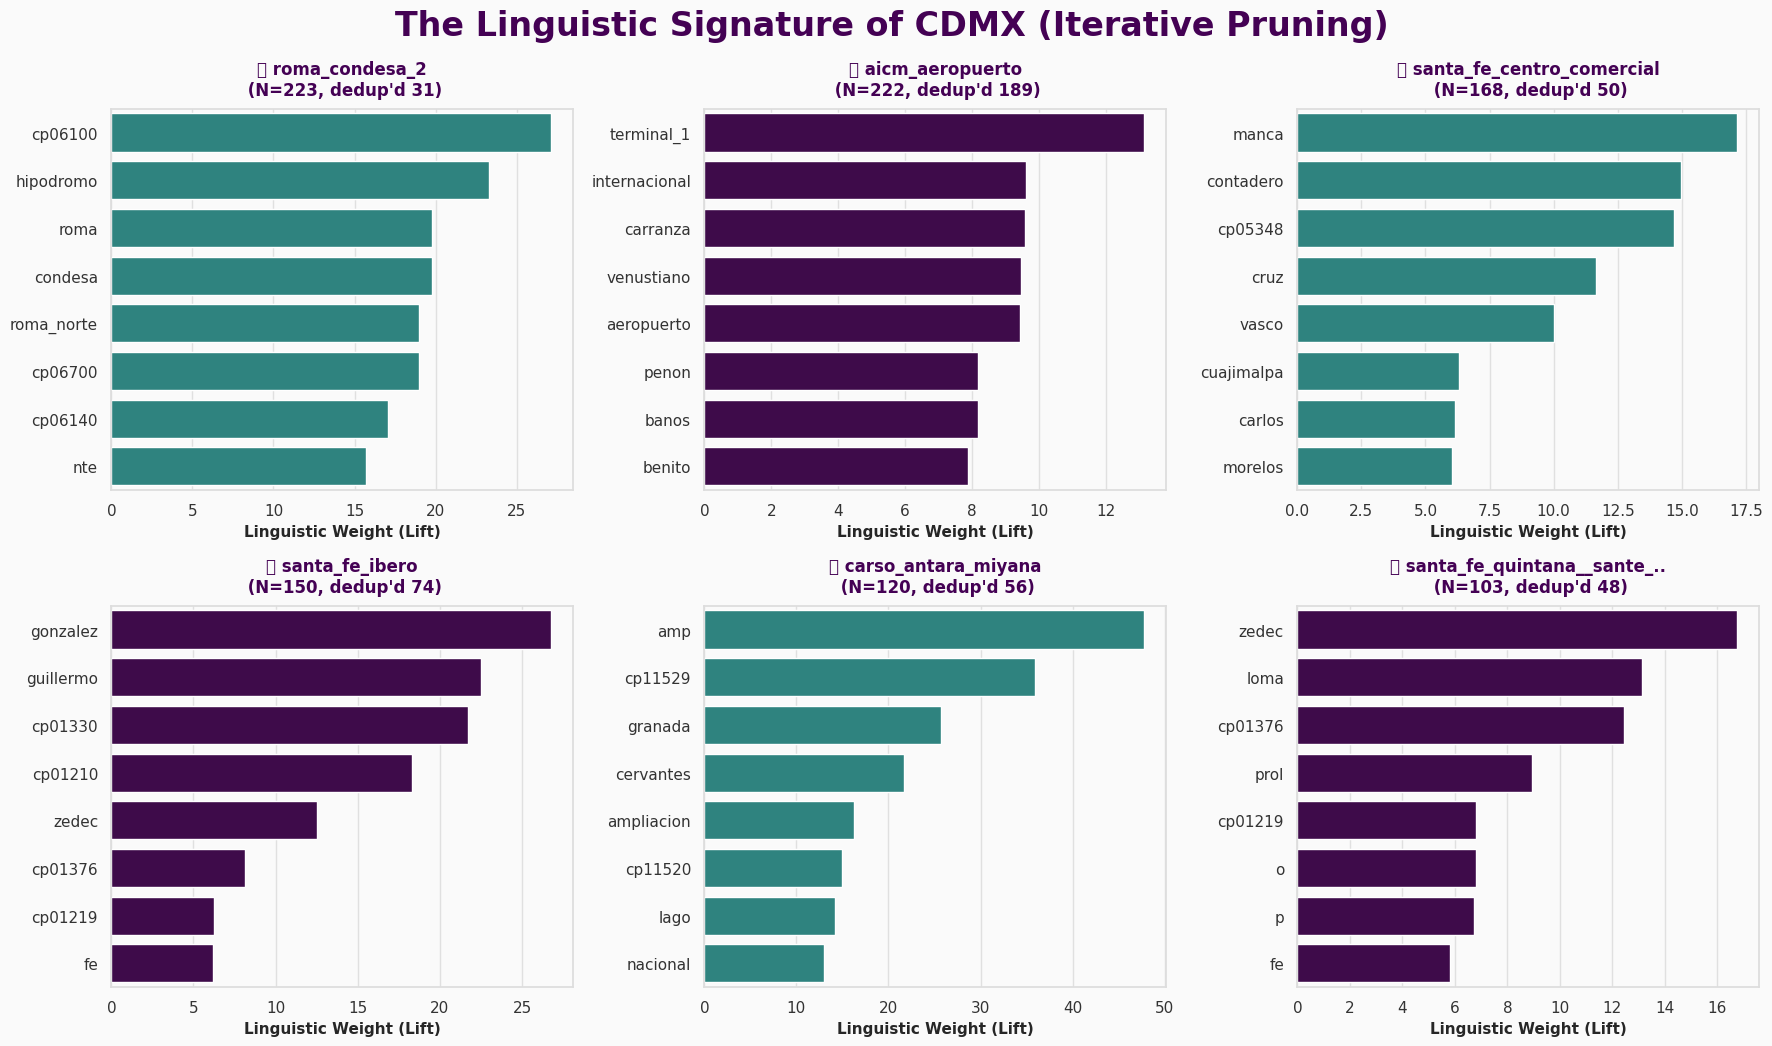

✅ Urban Lexicon visualizer successfully executed.


In [ ]:
# ==============================================================================
# CELL 8 (FIXED): ITERATIVE "URBAN LEXICON" VISUALIZER
# ==============================================================================
# Purpose: Extract the "Linguistic Signature" of each zone.
# Enhancements:
#   1. Intra-Zone Address Deduplication (Removes uniform bar clusters)
#   2. Min Global Count Filter (Suppresses unique token noise)
#   3. Dynamic sizing for small vs large zones
# ==============================================================================
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("🕵️‍♂️ Analyzing the DNA of Urban Vocabulary (Iterative Pruning Mode)...")

# --- 1. CONFIGURATION & PRUNING THRESHOLDS ---
TARGET_TOP_N_ZONES = 6
MIN_GLOBAL_WORD_COUNT = 3  # Word must appear at least 3 times globally

# Enforce the same canon from Cell 0
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'

# --- 2. GLOBAL PREPARATION (NOISE FILTERING) ---
# FIX: Using df_model and clean_address with a simple split
global_tokens = [t for addr in df_model['clean_address'] for t in str(addr).split()]
global_token_counts = Counter(global_tokens)
total_words_global = sum(global_token_counts.values())

# Identificamos el "Vocabulario Ruido" a nivel global (lo que no vale nada)
rare_global_words = {word for word, count in global_token_counts.items() if count < MIN_GLOBAL_WORD_COUNT}
print(f"✅ Noise-Pruning: Ignorando {len(rare_global_words)} palabras globales raras.")

# --- 3. AUDIT Y VISUALIZACIÓN ---
zone_lexicons = []

# Identificar las zonas de mayor volumen
# FIX: Using df_model
target_zones_counts = df_model['final_zone_name'].value_counts()
target_zones = target_zones_counts.nlargest(TARGET_TOP_N_ZONES).index.tolist()

# Crear el lienzo Opus
plt.figure(figsize=(18, 11), facecolor=OPUS_GREY)

for i, zone in enumerate(target_zones):
    plt.subplot(2, 3, i+1)

    # A. Intra-Zone Address Deduplication
    zone_addrs_df = df_model[df_model['final_zone_name'] == zone]

    initial_zone_len = len(zone_addrs_df)
    # FIX: Deduplicate based on the cleaned address
    unique_zone_addrs_df = zone_addrs_df.drop_duplicates(subset=['clean_address']).copy()
    num_addrs_deduplicated = initial_zone_len - len(unique_zone_addrs_df)

    # FIX: Tokenize using simple .split()
    zone_tokens = [t for addr in unique_zone_addrs_df['clean_address'] for t in str(addr).split()]

    # B. Apply Noise Pruning (remove globally rare words)
    zone_tokens_clean = [t for t in zone_tokens if t not in rare_global_words]

    zone_counts = Counter(zone_tokens_clean)
    num_zone_words = len(zone_tokens_clean)

    # If the zone is very small, force more distinction by picking fewer words
    top_N_most_common = 5 if num_zone_words < 100 else 8

    lift_data_for_zone = []

    # C. Calculate specificity ONLY for the clean, deduplicated intra-zone vocabulary
    for word, count in zone_counts.most_common(20):
        if count < 2: continue # Ignore tokens that only appear once inside a *clean* zone

        prob_zone = count / num_zone_words
        prob_global = global_token_counts[word] / total_words_global
        lift = prob_zone / prob_global

        lift_data_for_zone.append({
            'Zone': zone,
            'Word': word,
            'Count': count,
            'Specificity (Lift)': lift
        })

    # D. GRAFICAR (ENFORCED OPUS STYLE)
    df_lexicon_zone = pd.DataFrame(lift_data_for_zone)

    # Fallback safety check if the zone got completely pruned
    if df_lexicon_zone.empty:
        plt.title(f"📍 {zone}\n(Filtered out due to low variance)", fontsize=12, color=OPUS_PURPLE)
        continue

    top_words = df_lexicon_zone.nlargest(top_N_most_common, 'Specificity (Lift)').sort_values(by='Specificity (Lift)', ascending=False)

    bar_color = OPUS_TEAL if i % 2 == 0 else OPUS_PURPLE

    sns.barplot(
        data=top_words,
        x='Specificity (Lift)',
        y='Word',
        hue='Word',
        palette=[bar_color]*len(top_words),
        legend=False
    )

    # Limpieza estética del subplot
    short_name = (zone[:25] + '..') if len(zone) > 25 else zone
    subtitle = f"📍 {short_name}"
    subtitle_volume = f" (N={target_zones_counts[zone]}, dedup'd {num_addrs_deduplicated})"

    plt.title(f"{subtitle}\n{subtitle_volume}", fontsize=12, fontweight='bold', color=OPUS_PURPLE, pad=10)
    plt.xlabel("Linguistic Weight (Lift)", fontsize=11, fontweight='bold')
    plt.ylabel("")

# Título Principal
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("The Linguistic Signature of CDMX (Iterative Pruning)", fontsize=24, fontweight='bold', color=OPUS_PURPLE)
plt.show()

print("✅ Urban Lexicon visualizer successfully executed.")

In [ ]:
# ==============================================================================
# CELL 14 (FINAL V3): THE GIANT ARRIVES - BETO (BERT Spanish)
# ==============================================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
import torch

print("⏳ Awakening BETO (Spanish BERT) via AutoAPI...")

# 1. LOAD TOKENIZER & PREPARE DATA
model_name = "dccuchile/bert-base-spanish-wwm-cased"
# Using AutoTokenizer is more robust than calling BertTokenizer directly
tokenizer = AutoTokenizer.from_pretrained(model_name)

def bert_encode(addresses, max_len=64):
    input_ids = []
    attention_masks = []
    for addr in addresses:
        # We call the tokenizer object directly (Modern Standard)
        encoded = tokenizer(
            str(addr),
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            return_attention_mask=True,
            truncation=True,
            return_tensors='pt'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

# 2. DATA PREPARATION
print("⏳ Tokenizing for BERT...")
train_ids, train_masks = bert_encode(X_train)
val_ids, val_masks = bert_encode(X_val)

train_y = torch.tensor([zone_to_idx[y] for y in y_train])
val_y = torch.tensor([zone_to_idx[y] for y in y_val])

bert_train_ds = TensorDataset(train_ids, train_masks, train_y)
bert_val_ds = TensorDataset(val_ids, val_masks, val_y)
bert_train_loader = DataLoader(bert_train_ds, batch_size=16, shuffle=True)
bert_val_loader = DataLoader(bert_val_ds, batch_size=16)

# 3. LOAD MODEL
print("⏳ Loading Pre-trained Weights...")
model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(unique_zones)
).to(device)

# 4. OPTIMIZER
optimizer = AdamW(model_bert.parameters(), lr=2e-5, eps=1e-8)
epochs = 20

print(f"🚀 Fine-tuning BETO on {device}...")

for epoch in range(epochs):
    model_bert.train()
    total_loss = 0
    for batch in bert_train_loader:
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
        model_bert.zero_grad()

        outputs = model_bert(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    # Validation
    model_bert.eval()
    all_preds = []
    with torch.no_grad():
        for batch in bert_val_loader:
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            outputs = model_bert(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).flatten()
            all_preds.extend(preds.cpu().numpy())

    val_acc_bert = accuracy_score(val_y.numpy(), all_preds)
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(bert_train_loader):.4f} | Val Acc: {val_acc_bert:.4%}")



⏳ Awakening BETO (Spanish BERT) via AutoAPI...
⏳ Tokenizing for BERT...
⏳ Loading Pre-trained Weights...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

🚀 Fine-tuning BETO on cuda...
Epoch 01 | Loss: 3.1714 | Val Acc: 47.4926%
Epoch 02 | Loss: 1.9612 | Val Acc: 60.0295%
Epoch 03 | Loss: 1.4041 | Val Acc: 66.0767%
Epoch 04 | Loss: 1.0769 | Val Acc: 71.6814%
Epoch 05 | Loss: 0.8187 | Val Acc: 77.5811%
Epoch 06 | Loss: 0.6236 | Val Acc: 78.4661%
Epoch 07 | Loss: 0.4934 | Val Acc: 81.2684%
Epoch 08 | Loss: 0.3757 | Val Acc: 83.4808%
Epoch 09 | Loss: 0.3201 | Val Acc: 81.7109%
Epoch 10 | Loss: 0.2395 | Val Acc: 83.9233%
Epoch 11 | Loss: 0.1855 | Val Acc: 84.2183%
Epoch 12 | Loss: 0.1607 | Val Acc: 85.6932%
Epoch 13 | Loss: 0.1241 | Val Acc: 83.3333%
Epoch 14 | Loss: 0.1062 | Val Acc: 84.2183%
Epoch 15 | Loss: 0.1031 | Val Acc: 84.3658%
Epoch 16 | Loss: 0.0914 | Val Acc: 85.6932%
Epoch 17 | Loss: 0.1089 | Val Acc: 84.2183%
Epoch 18 | Loss: 0.0913 | Val Acc: 84.3658%
Epoch 19 | Loss: 0.0787 | Val Acc: 84.0708%
Epoch 20 | Loss: 0.0727 | Val Acc: 84.6608%
